In [3]:
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [4]:
SEED = 323
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [5]:
df = pd.read_csv('group_20_1.csv')
feature_cols = ['Age', 'Gender', 'Education', 'Country', 'Ethnicity',
                'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore',
                'Impulsive', 'SS']
X = df[feature_cols].values
y = df['Amyl'].values


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
y_train_s1 = (y_train != 0).astype(int)
y_test_s1  = (y_test  != 0).astype(int)
print(X_train.shape)
print(np.bincount(y_train_s1))
print(np.bincount(y_test_s1))

(1508, 12)
[1044  464]
[261 116]


In [31]:
class BinaryNet(nn.Module):
    def __init__(self, input_dim):
        super(BinaryNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)

In [38]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_s1_t = torch.tensor(y_train_s1, dtype=torch.float32).unsqueeze(1)
y_test_s1_t  = torch.tensor(y_test_s1,  dtype=torch.float32).unsqueeze(1)
train_ds = TensorDataset(X_train_t, y_train_s1_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
torch.manual_seed(SEED)
model_s1 = BinaryNet(input_dim=12)
pos_weight = torch.tensor([1044 / 464])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_s1.parameters(), lr=0.001)
EPOCHS = 200

for epoch in range(EPOCHS):
    model_s1.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model_s1(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}  Loss: {total_loss/len(train_loader):.4f}")

Epoch 10/200  Loss: 0.8526
Epoch 20/200  Loss: 0.8242
Epoch 30/200  Loss: 0.8054
Epoch 40/200  Loss: 0.7789
Epoch 50/200  Loss: 0.7960
Epoch 60/200  Loss: 0.7916
Epoch 70/200  Loss: 0.7726
Epoch 80/200  Loss: 0.7649
Epoch 90/200  Loss: 0.7901
Epoch 100/200  Loss: 0.7875
Epoch 110/200  Loss: 0.7608
Epoch 120/200  Loss: 0.7511
Epoch 130/200  Loss: 0.7737
Epoch 140/200  Loss: 0.7404
Epoch 150/200  Loss: 0.7272
Epoch 160/200  Loss: 0.7159
Epoch 170/200  Loss: 0.7432
Epoch 180/200  Loss: 0.7104
Epoch 190/200  Loss: 0.6971
Epoch 200/200  Loss: 0.7337


In [39]:
model_s1.eval()
with torch.no_grad():
    preds_s1 = (model_s1(X_test_t).squeeze().numpy() >= 0.5).astype(int)

print(classification_report(y_test_s1, preds_s1, target_names=['CL0', 'Others']))
print(confusion_matrix(y_test_s1, preds_s1))

              precision    recall  f1-score   support

         CL0       0.78      0.90      0.83       261
      Others       0.65      0.41      0.51       116

    accuracy                           0.75       377
   macro avg       0.71      0.66      0.67       377
weighted avg       0.74      0.75      0.73       377

[[235  26]
 [ 68  48]]


In [40]:
mask_train_s2 = (y_train != 0)
X_train_s2 = X_train[mask_train_s2]
y_train_s2 = (y_train[mask_train_s2] - 1).clip(0)  
mask_test_s2 = (preds_s1 == 1)
X_test_s2 = X_test[mask_test_s2]
y_test_s2 = (y_test[mask_test_s2] - 1).clip(0)
print("Stage2 train set:", X_train_s2.shape, "distribution:", np.bincount(y_train_s2))
print("Stage2 test set:", X_test_s2.shape)

Stage2 train set: (464, 12) distribution: [168 296]
Stage2 test set: (74, 12)


In [47]:
X_train_s2_t = torch.tensor(X_train_s2, dtype=torch.float32)
X_test_s2_t  = torch.tensor(X_test_s2,  dtype=torch.float32)
y_train_s2_t = torch.tensor(y_train_s2, dtype=torch.float32).unsqueeze(1)
y_test_s2_t  = torch.tensor(y_test_s2,  dtype=torch.float32).unsqueeze(1)

train_ds_s2 = TensorDataset(X_train_s2_t, y_train_s2_t)
train_loader_s2 = DataLoader(train_ds_s2, batch_size=32, shuffle=True)

torch.manual_seed(SEED)
model_s2 = BinaryNet(input_dim=12)
pos_weight_s2 = torch.tensor([168 / 296])
criterion_s2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight_s2)
optimizer_s2 = torch.optim.Adam(model_s2.parameters(), lr=0.001)

EPOCHS = 20
for epoch in range(EPOCHS):
    model_s2.train()
    total_loss = 0
    for X_batch, y_batch in train_loader_s2:
        optimizer_s2.zero_grad()
        loss = criterion_s2(model_s2(X_batch), y_batch)
        loss.backward()
        optimizer_s2.step()
        total_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}  Loss: {total_loss/len(train_loader_s2):.4f}")

Epoch 10/20  Loss: 0.3803
Epoch 20/20  Loss: 0.3602


In [48]:
model_s2.eval()
with torch.no_grad():
    preds_s2 = (model_s2(X_test_s2_t).squeeze().numpy() >= 0.5).astype(int)

final_preds = np.zeros(len(y_test), dtype=int)
final_preds[np.where(mask_test_s2)[0]] = preds_s2 + 1

print(classification_report(y_test_s2, preds_s2, target_names=['CL1','CL2']))
print(classification_report(y_test, final_preds, target_names=['CL0','CL1','CL2']))
print("Confusion matrix\n", confusion_matrix(y_test, final_preds))

              precision    recall  f1-score   support

         CL1       0.71      0.71      0.71        41
         CL2       0.64      0.64      0.64        33

    accuracy                           0.68        74
   macro avg       0.67      0.67      0.67        74
weighted avg       0.68      0.68      0.68        74

              precision    recall  f1-score   support

         CL0       0.78      0.90      0.83       261
         CL1       0.29      0.29      0.29        42
         CL2       0.64      0.28      0.39        74

    accuracy                           0.71       377
   macro avg       0.57      0.49      0.51       377
weighted avg       0.69      0.71      0.69       377

Confusion matrix
 [[235  17   9]
 [ 27  12   3]
 [ 41  12  21]]


In [51]:
def get_preds(model, X):
    model.eval()
    with torch.no_grad():
        return (model(torch.tensor(X, dtype=torch.float32)
                      ).squeeze().numpy() >= 0.5).astype(int)

train_acc_s1 = (get_preds(model_s1, X_train) == (y_train != 0).astype(int)).mean()
test_acc_s1  = (preds_s1 == y_test_s1).mean()
print(f"Stage1 train set accuracy: {train_acc_s1:.3f}")
print(f"Stage1 test set accuracy: {test_acc_s1:.3f}")

train_acc_s2 = (get_preds(model_s2, X_train_s2) == y_train_s2).mean()
test_acc_s2  = (preds_s2 == y_test_s2).mean()
print(f"Stage2 train sey accuracy: {train_acc_s2:.3f}")
print(f"Stage2 test set accuracy: {test_acc_s2:.3f}")

Stage1 train set accuracy: 0.810
Stage1 test set accuracy: 0.751
Stage2 train sey accuracy: 0.752
Stage2 test set accuracy: 0.676


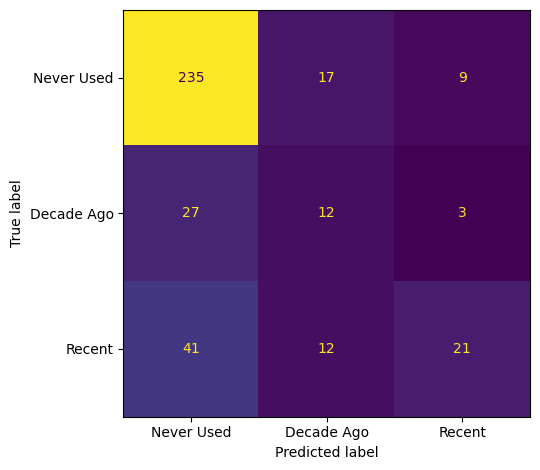

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test, final_preds,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.tight_layout()
plt.show()

In [53]:
# KNN

In [55]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
preds_knn = knn.predict(X_test)
print(classification_report(y_test, preds_knn, target_names=['Never Used', 'Decade Ago', 'Recent']))

              precision    recall  f1-score   support

  Never Used       0.73      0.92      0.81       261
  Decade Ago       0.36      0.12      0.18        42
      Recent       0.42      0.18      0.25        74

    accuracy                           0.69       377
   macro avg       0.50      0.41      0.41       377
weighted avg       0.62      0.69      0.63       377



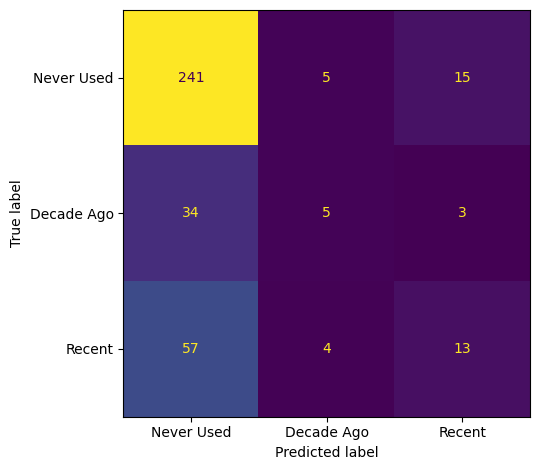

In [56]:
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_knn,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

  Never Used       0.73      0.89      0.80       261
  Decade Ago       0.21      0.10      0.13        42
      Recent       0.45      0.24      0.32        74

    accuracy                           0.67       377
   macro avg       0.46      0.41      0.42       377
weighted avg       0.62      0.67      0.63       377



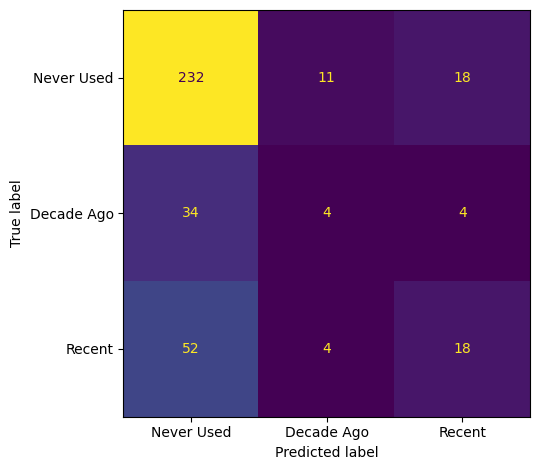

In [57]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
preds_knn = knn.predict(X_test)
print(classification_report(y_test, preds_knn, target_names=['Never Used', 'Decade Ago', 'Recent']))
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_knn,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

  Never Used       0.74      0.92      0.82       261
  Decade Ago       0.29      0.10      0.14        42
      Recent       0.53      0.26      0.35        74

    accuracy                           0.70       377
   macro avg       0.52      0.43      0.44       377
weighted avg       0.65      0.70      0.65       377



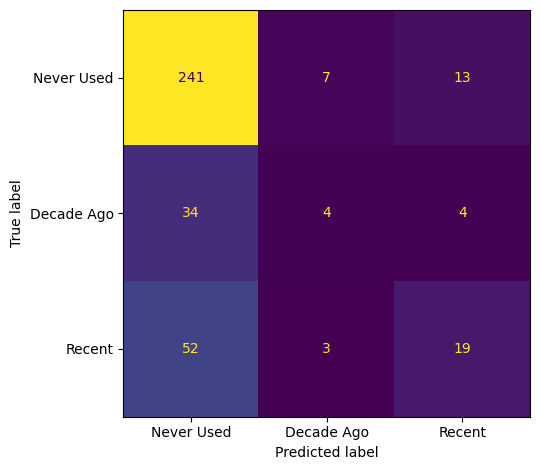

In [58]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
preds_knn = knn.predict(X_test)
print(classification_report(y_test, preds_knn, target_names=['Never Used', 'Decade Ago', 'Recent']))
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_knn,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

  Never Used       0.73      0.95      0.83       261
  Decade Ago       0.43      0.07      0.12        42
      Recent       0.53      0.22      0.31        74

    accuracy                           0.71       377
   macro avg       0.56      0.41      0.42       377
weighted avg       0.66      0.71      0.65       377



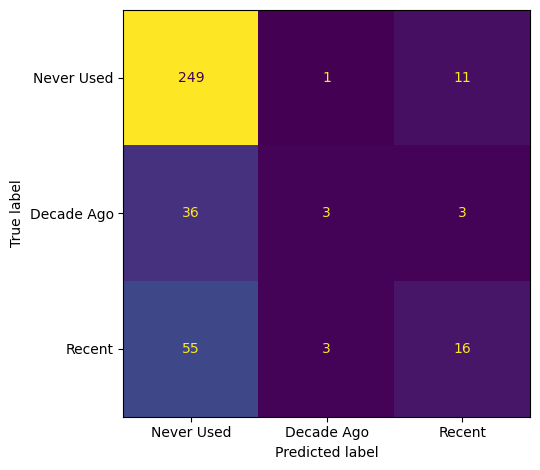

In [59]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)
preds_knn = knn.predict(X_test)
print(classification_report(y_test, preds_knn, target_names=['Never Used', 'Decade Ago', 'Recent']))
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_knn,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

  Never Used       0.73      0.95      0.83       261
  Decade Ago       0.43      0.07      0.12        42
      Recent       0.62      0.24      0.35        74

    accuracy                           0.72       377
   macro avg       0.59      0.42      0.43       377
weighted avg       0.68      0.72      0.65       377



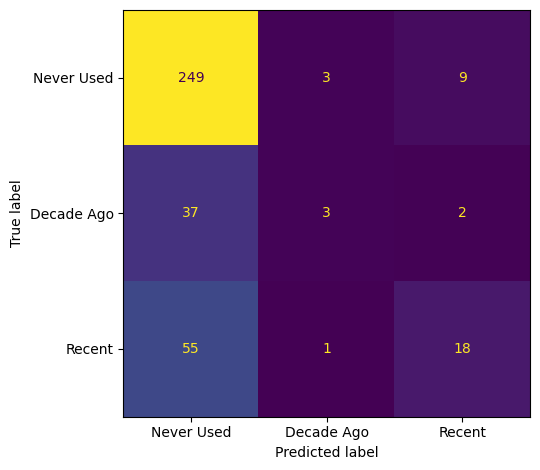

In [60]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
preds_knn = knn.predict(X_test)
print(classification_report(y_test, preds_knn, target_names=['Never Used', 'Decade Ago', 'Recent']))
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_knn,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

  Never Used       0.72      0.94      0.82       261
  Decade Ago       0.38      0.07      0.12        42
      Recent       0.52      0.19      0.28        74

    accuracy                           0.70       377
   macro avg       0.54      0.40      0.40       377
weighted avg       0.64      0.70      0.63       377



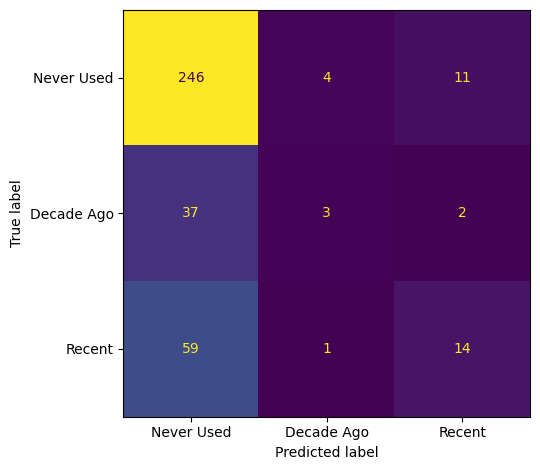

In [62]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train, y_train)
preds_knn = knn.predict(X_test)
print(classification_report(y_test, preds_knn, target_names=['Never Used', 'Decade Ago', 'Recent']))
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_knn,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.tight_layout()
plt.show()